# Mini-Proyecto: Generacion de Texto Financiero con GPT-2

Se aplica fine-tuning de un modelo GPT-2 en espanol sobre un corpus de articulos
financieros extraidos de Wikipedia, y se analiza como cambia la generacion de
texto antes y despues del entrenamiento.

### Flujo
1. Entorno y configuracion
2. Carga del modelo base
3. Funciones de generacion y evaluacion
4. Generacion baseline
5. Corpus financiero
6. Fine-tuning
7. Comparacion base vs fine-tuned
8. Analisis: perplejidad, sentimiento y vocabulario
9. Conclusiones

### Configuracion
| Parametro | Valor |
|---|---|
| Modelo | mrm8488/spanish-gpt2 |
| Dataset | Wikipedia ES — articulos de economia y finanzas |
| Sentimiento | pysentimiento (BERT en espanol) |
| Semilla | 42 |

## 1. Entorno y Configuracion

In [ ]:
!pip install transformers datasets accelerate pysentimiento wordcloud matplotlib seaborn -q

In [ ]:
import math
import random
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import transformers
import datasets as ds_lib
from datasets import Dataset, load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("Blues_r")

# -- Semilla global para reproducibilidad -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -- Dispositivo -------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# -- Informacion del entorno -------------------------------------------
import platform
print("Entorno de ejecucion")
print(f"  Python       : {platform.python_version()}")
print(f"  PyTorch      : {torch.__version__}")
print(f"  Transformers : {transformers.__version__}")
print(f"  Datasets     : {ds_lib.__version__}")
print(f"  CUDA         : {torch.version.cuda}")
print(f"  Dispositivo  : {device}")
if device == "cuda":
    print(f"  GPU          : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"  Semilla      : {SEED}")

Entorno de ejecucion
  Python       : 3.12.13
  PyTorch      : 2.10.0+cu128
  Transformers : 5.0.0
  Datasets     : 4.0.0
  CUDA         : 12.8
  Dispositivo  : cuda
  GPU          : Tesla T4
  VRAM         : 15.6 GB
  Semilla      : 42


## 2. Carga del Modelo Base

Se usa `mrm8488/spanish-gpt2`, un GPT-2 decoder-only preentrenado en espanol.
Predice el siguiente token dado el contexto anterior.

Despues de cargarlo se llama a `resize_token_embeddings` para sincronizar la
tabla de embeddings con el tokenizador. Sin este paso el modelo puede recibir
IDs fuera del rango de la tabla de entrada y producir un CUDA device-side assert.

In [ ]:
MODEL_NAME = "mrm8488/spanish-gpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model_base = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model_base.config.pad_token_id = tokenizer.pad_token_id
model_base.resize_token_embeddings(len(tokenizer))

VOCAB_SIZE = model_base.transformer.wte.num_embeddings

print("Modelo      :", MODEL_NAME)
print("Vocabulario :", f"{VOCAB_SIZE:,}", "tokens")
print("Parametros  :", f"{sum(p.numel() for p in model_base.parameters()):,}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Modelo      : mrm8488/spanish-gpt2
Vocabulario : 50,266 tokens
Parametros  : 124,446,720


## 3. Funciones de Generacion y Evaluacion

| Estrategia | Descripcion | Parametro |
|---|---|---|
| Greedy | Siempre el token mas probable | — |
| Top-k | Muestrea entre los k mas probables | k |
| Top-p | Muestrea con prob. acumulada >= p | p |
| Temperature | T < 1 conservador, T > 1 creativo | T |

La funcion `generar_texto` acepta un parametro `seed` opcional para fijar la
semilla antes de cada generacion estocastica y garantizar reproducibilidad.

In [ ]:
def generar_texto(
    model,
    tokenizer,
    prompt,
    estrategia="greedy",
    max_new_tokens=100,
    top_k=50,
    top_p=0.92,
    temperature=1.0,
    device="cpu",
    seed=None,
):
    """
    Genera texto a partir de un prompt usando la estrategia indicada.
    Devuelve unicamente los tokens nuevos (sin el prompt).
    El parametro seed fija la aleatoriedad para resultados reproducibles.
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    n = inputs["input_ids"].shape[1]

    kwargs = {
        "max_new_tokens": max_new_tokens,
        "pad_token_id": tokenizer.eos_token_id,
        "do_sample": False,
    }
    if estrategia == "top_k":
        kwargs.update({"do_sample": True, "top_k": top_k, "temperature": temperature})
    elif estrategia == "top_p":
        kwargs.update({"do_sample": True, "top_p": top_p, "top_k": 0, "temperature": temperature})
    elif estrategia == "temperature":
        kwargs.update({"do_sample": True, "temperature": temperature, "top_k": 0})

    if seed is not None and kwargs["do_sample"]:
        torch.manual_seed(seed)

    with torch.no_grad():
        out = model.generate(**inputs, **kwargs)

    return tokenizer.decode(out[0][n:], skip_special_tokens=True)


def calcular_perplejidad(model, tokenizer, texto, device="cpu"):
    """
    Perplejidad de un texto dado el modelo.
    Menor valor indica que el modelo encuentra el texto mas natural.
    """
    enc = tokenizer(texto, return_tensors="pt").to(device)
    with torch.no_grad():
        loss = model(**enc, labels=enc["input_ids"]).loss.item()
    if math.isnan(loss) or math.isinf(loss):
        return float("nan")
    return math.exp(min(loss, 20))


def verificar_modelo(model, tokenizer, device, nombre=""):
    """Comprueba si el modelo tiene pesos validos tras el entrenamiento."""
    enc = tokenizer(
        "El banco central subio las tasas de interes",
        return_tensors="pt",
    ).to(device)
    with torch.no_grad():
        loss = model(**enc, labels=enc["input_ids"]).loss.item()
    ok = not (math.isnan(loss) or math.isinf(loss) or loss > 50)
    perp = math.exp(min(loss, 20)) if ok else float("nan")
    estado = "Estable" if ok else "INESTABLE"
    print(f"  {nombre:15s}  loss={loss:.4f}  perpl={perp:.1f}  [{estado}]")
    return ok


print("Funciones definidas")

Funciones definidas


## 4. Generacion Baseline

Se prueba el modelo base con prompts financieros usando todas las estrategias
de decodificacion. Esto establece el punto de referencia antes del fine-tuning.

Se usa `seed=SEED` en las estrategias estocasticas para que los resultados
sean reproducibles en cada ejecucion del notebook.

In [ ]:
PROMPTS = [
    "El Banco de la Republica decidio aumentar",
    "La inflacion en Colombia durante el ultimo trimestre",
    "Los inversionistas en la Bolsa de Valores de Colombia",
    "El credito hipotecario en el sector bancario",
]

ESTRATEGIAS = [
    {"nombre": "Greedy",       "est": "greedy",      "p": {}},
    {"nombre": "Top-k (k=50)", "est": "top_k",       "p": {"top_k": 50, "temperature": 1.0}},
    {"nombre": "Top-p (0.92)", "est": "top_p",       "p": {"top_p": 0.92, "temperature": 1.0}},
    {"nombre": "Temp = 0.5",   "est": "temperature", "p": {"temperature": 0.5}},
    {"nombre": "Temp = 1.2",   "est": "temperature", "p": {"temperature": 1.2}},
]

print("BASELINE - modelo sin fine-tuning")
print("=" * 65)

rows_base = []
for prompt in PROMPTS:
    print()
    print("Prompt:", repr(prompt))
    print("-" * 60)
    for e in ESTRATEGIAS:
        t = generar_texto(
            model_base, tokenizer, prompt,
            estrategia=e["est"], max_new_tokens=80,
            device=device, seed=SEED, **e["p"],
        )
        print(f"  [{e['nombre']}]  {t[:140]}...")
        rows_base.append({"prompt": prompt, "estrategia": e["nombre"], "texto": t})

df_baseline = pd.DataFrame(rows_base)

BASELINE - modelo sin fine-tuning

Prompt: 'El Banco de la Republica decidio aumentar'
------------------------------------------------------------
  [Greedy]   el capital de la empresa de la familia de la familia de la familia de la familia de la familia de la familia de la familia de la familia de...
  [Top-k (k=50)]   su capital con el fin de garantizar el sostenimiento de los gastos, y reducirlo, por ahora, para cubrir sus gastos con el monto total de su...
  [Top-p (0.92)]   su capital con el fin de garantizar el sostenimiento de los 2,838,194 l de nuevos créditos y la creacion del Fondo de Garanias.Septiembre 1...
  [Temp = 0.5]   su capital de 5 millones de euros a 10 millones de euros.El Banco de la Republica de San Marino ha tomado la decisión de aumentar su capita...
  [Temp = 1.2]   su cuantitativa para prevenir que una zona encoge hacer llenar el 2,8% del crecimiento del MIG.OK $ Syn se marca que total en su 90% los do...

Prompt: 'La inflacion en Colombia durante el ultimo

## 5. Corpus Financiero (Wikipedia ES)

Se filtran articulos de Wikipedia en espanol que contengan al menos 3 terminos
del dominio financiero/bancario. El resultado es un corpus formal y tecnico,
opuesto al estilo general del modelo base, lo que hace visible el cambio de
distribucion tras el fine-tuning.

In [ ]:
# Lista unica de terminos financieros (con tildes para busqueda en Wikipedia)
TERMINOS = [
    "banco", "inversion", "bolsa de valores", "mercado financiero",
    "credito", "inflacion", "tasa de interes", "acciones", "deuda publica",
    "dividendo", "cartera", "fondo de inversion", "presupuesto", "deficit",
    "tipo de cambio", "moneda", "reservas internacionales", "banca",
    "economia", "producto interno bruto", "pib", "rentabilidad",
    "activo", "pasivo", "emision", "bonos", "hipoteca", "liquidez",
]


def es_financiero(texto):
    t = texto.lower()
    return sum(1 for w in TERMINOS if w in t) >= 3


def limpiar(texto):
    texto = re.sub(r"\[\d+\]", "", texto)
    texto = re.sub(r"\[\[.*?\]\]", "", texto)
    texto = re.sub(r"==.*?==", "", texto)
    return re.sub(r"\s+", " ", texto).strip()


print("Cargando Wikipedia en espanol (streaming)...")
wiki = load_dataset(
    "wikimedia/wikipedia", "20231101.es",
    split="train", streaming=True,
)

textos, revisados = [], 0
TARGET = 1500

for art in wiki:
    revisados += 1
    t = limpiar(art["text"])
    if len(t) > 300 and es_financiero(t):
        textos.append(t[:1500])
    if len(textos) >= TARGET:
        break
    if revisados % 5000 == 0:
        print(f"  Revisados: {revisados:,} | Financieros: {len(textos)}")

corpus_completo = " ".join(textos).lower()
print(f"Corpus: {len(textos)} articulos, {len(corpus_completo):,} caracteres")

Cargando Wikipedia en espanol (streaming)...
  Revisados: 5,000 | Financieros: 527
  Revisados: 10,000 | Financieros: 794
  Revisados: 15,000 | Financieros: 1079
  Revisados: 20,000 | Financieros: 1414
Corpus: 1500 articulos, 2,250,238 caracteres


### 5.1 Analisis Exploratorio del Corpus

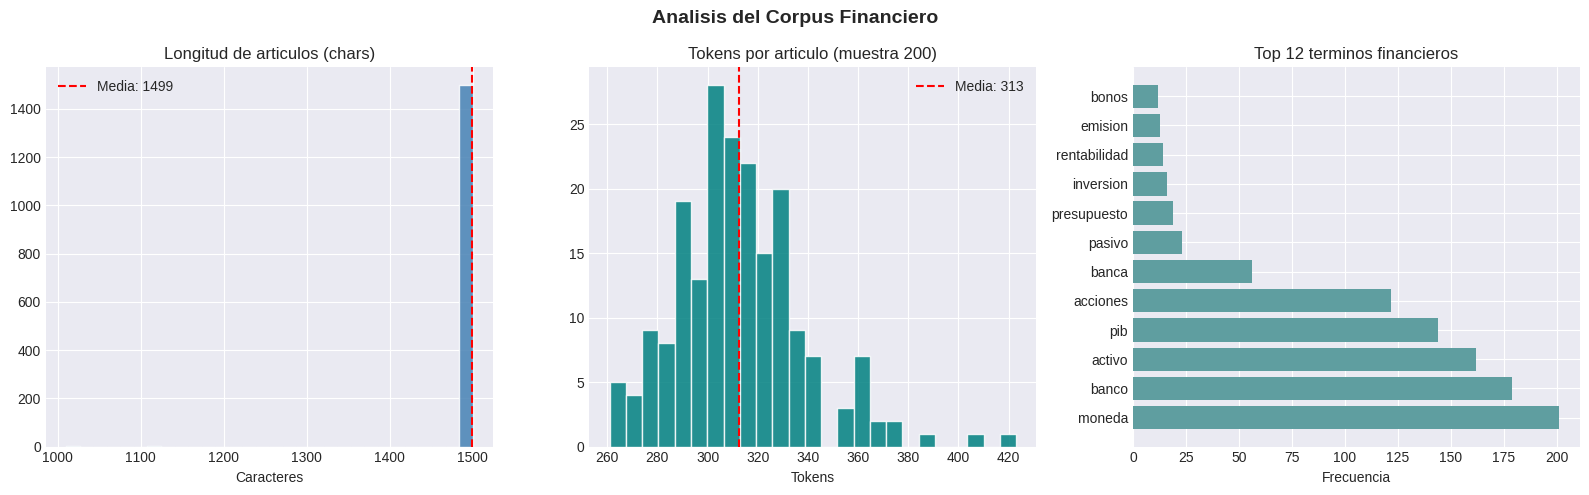

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Analisis del Corpus Financiero", fontsize=14, fontweight="bold")

longs = [len(t) for t in textos]
axes[0].hist(longs, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(np.mean(longs), color="red", linestyle="--",
                label=f"Media: {np.mean(longs):.0f}")
axes[0].set_title("Longitud de articulos (chars)")
axes[0].set_xlabel("Caracteres")
axes[0].legend()

ntoks = [len(tokenizer.encode(t)) for t in textos[:200]]
axes[1].hist(ntoks, bins=25, color="teal", edgecolor="white", alpha=0.85)
axes[1].axvline(np.mean(ntoks), color="red", linestyle="--",
                label=f"Media: {np.mean(ntoks):.0f}")
axes[1].set_title("Tokens por articulo (muestra 200)")
axes[1].set_xlabel("Tokens")
axes[1].legend()

simples = [w for w in TERMINOS if len(w.split()) == 1]
conteo = {w: corpus_completo.count(w) for w in simples}
conteo = dict(sorted(conteo.items(), key=lambda x: x[1], reverse=True)[:12])
axes[2].barh(list(conteo.keys()), list(conteo.values()), color="cadetblue")
axes[2].set_title("Top 12 terminos financieros")
axes[2].set_xlabel("Frecuencia")

plt.tight_layout()
plt.savefig("corpus_stats.png", dpi=150, bbox_inches="tight")
plt.show()

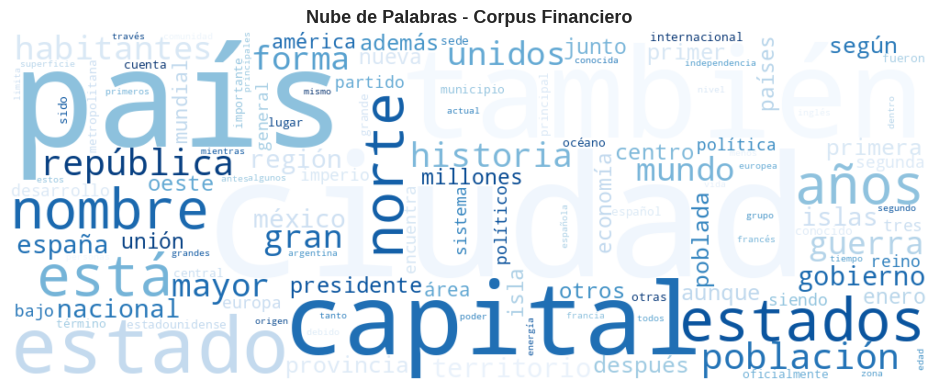

In [ ]:
STOPWORDS_ES = {
    "de", "la", "el", "en", "y", "a", "que", "los", "se", "del", "las", "un",
    "por", "con", "una", "su", "es", "para", "como", "mas", "al", "lo", "le",
    "no", "o", "sus", "pero", "este", "esta", "fue", "ha", "son", "tambien",
    "entre", "cuando", "hasta", "sin", "sobre", "ser", "han", "todo", "puede",
    "si", "anos", "ano", "asi", "otro", "muy", "donde", "ya", "cual",
    "durante", "cada", "partir", "desde", "parte", "tiene", "tras",
}

# re.findall sin \b: compatible con caracteres acentuados
palabras = re.findall(r"[a-záéíóúñ]{4,}", corpus_completo)
freq_wc = Counter(w for w in palabras if w not in STOPWORDS_ES)

wc = WordCloud(
    width=1000, height=380,
    background_color="white",
    colormap="Blues",
    max_words=120,
).generate_from_frequencies(freq_wc)

plt.figure(figsize=(14, 4))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras - Corpus Financiero", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Fine-tuning

El corpus se divide en 85% entrenamiento (3,144 bloques) y 15% validacion
(561 bloques) para monitorear la generalizacion del modelo por epoca y recuperar
el mejor checkpoint al final del entrenamiento.

| Parametro | Valor | Justificacion |
|---|---|---|
| num_train_epochs | 5 | Permite convergencia completa; la curva de validacion confirma que no hay overfitting |
| learning_rate | 1e-5 | Conservador para fine-tuning sobre modelo preentrenado; tasas altas causan divergencia |
| warmup_steps | 100 | Calentamiento gradual del learning rate para estabilizar los primeros pasos |
| max_grad_norm | 1.0 | Gradient clipping — previene explosion de gradientes en textos largos |
| weight_decay | 0.01 | Regularizacion L2 para reducir overfitting |
| block_size | 128 | Compromiso entre contexto util y eficiencia de memoria en T4 |
| fp16 / bf16 | False | Desactivado; el grad scaler de precision mixta produce errores con este checkpoint |
| resize_token_embeddings | Si | Sincroniza el tamano de la tabla de entrada (wte) con el tokenizador; sin este paso se produce un CUDA device-side assert durante el forward pass |

In [ ]:
BLOCK_SIZE = 128


def preparar_dataset(textos, tokenizer, block_size=128):
    """
    Tokeniza el corpus y lo divide en bloques de longitud fija.
    resize_token_embeddings() garantiza que todos los IDs son validos.
    """
    ids_total = []
    for t in textos:
        ids = tokenizer.encode(t, add_special_tokens=True)
        ids.append(tokenizer.eos_token_id)
        ids_total.extend(ids)
    n = (len(ids_total) // block_size) * block_size
    chunks = [ids_total[i: i + block_size] for i in range(0, n, block_size)]
    return Dataset.from_dict({"input_ids": chunks})

In [ ]:
model_ft = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model_ft.config.pad_token_id = tokenizer.pad_token_id
model_ft.resize_token_embeddings(len(tokenizer))

split = int(len(textos) * 0.85)
ds_train = preparar_dataset(textos[:split], tokenizer, BLOCK_SIZE)
ds_val   = preparar_dataset(textos[split:], tokenizer, BLOCK_SIZE)

training_args = TrainingArguments(
    output_dir="./gpt2-financiero",
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=1e-5,
    warmup_steps=100,
    max_grad_norm=1.0,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=False,
    bf16=False,
    report_to="none",
    seed=SEED,
)

collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model_ft,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    data_collator=collator,
)

print("Configuracion lista")
print(f"  epochs     : {training_args.num_train_epochs}")
print(f"  train      : {len(ds_train):,} bloques")
print(f"  val        : {len(ds_val):,} bloques")
print(f"  lr         : {training_args.learning_rate}")
print(f"  seed       : {training_args.seed}")
print(f"  fp16/bf16  : {training_args.fp16}/{training_args.bf16}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Configuracion lista
  epochs     : 5
  train      : 3,144 bloques
  val        : 561 bloques
  lr         : 1e-05
  seed       : 42
  fp16/bf16  : False/False


In [ ]:
%%time
print("Entrenando...")
result = trainer.train()
print("Entrenamiento completo")
print(f"  Loss promedio : {result.training_loss:.4f}")
print(f"  Pasos         : {result.global_step}")

Entrenando...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,2.827813,2.808212
2,2.803003,2.789857
3,2.684789,2.782535
4,2.476034,2.780260
5,2.624938,2.780286


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Entrenamiento completo
  Loss promedio : 2.6930
  Pasos         : 3930
CPU times: user 11min 50s, sys: 8.84 s, total: 11min 59s
Wall time: 14min 23s


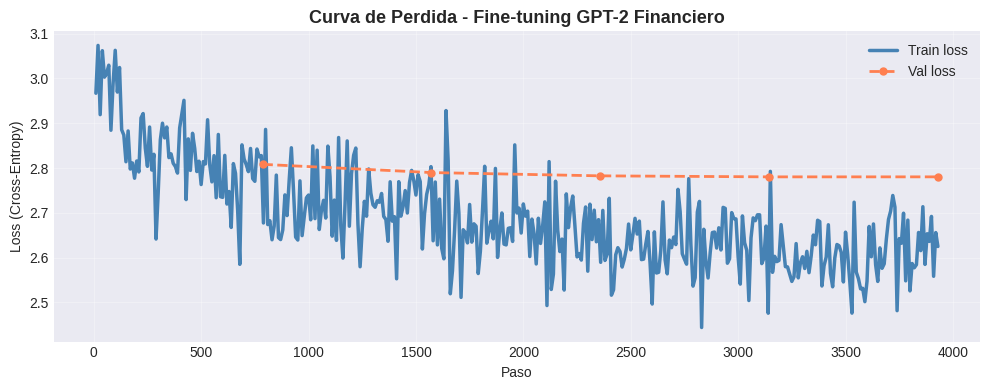

Loss train inicio -> fin : 2.9669 -> 2.6249
Loss val   inicio -> fin : 2.8082 -> 2.7803


In [ ]:
train_logs = [x for x in trainer.state.log_history
              if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in trainer.state.log_history if "eval_loss" in x]
steps_t = [x["step"] for x in train_logs]
loss_t  = [x["loss"]  for x in train_logs]
steps_e = [x["step"] for x in eval_logs]
loss_e  = [x["eval_loss"] for x in eval_logs]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps_t, loss_t, color="steelblue", linewidth=2.5, label="Train loss")
if steps_e:
    ax.plot(steps_e, loss_e, color="coral", linewidth=2, linestyle="--",
            marker="o", markersize=5, label="Val loss")
ax.set_title("Curva de Perdida - Fine-tuning GPT-2 Financiero",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Paso")
ax.set_ylabel("Loss (Cross-Entropy)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("curva_perdida.png", dpi=150, bbox_inches="tight")
plt.show()

if loss_t:
    print(f"Loss train inicio -> fin : {loss_t[0]:.4f} -> {loss_t[-1]:.4f}")
if loss_e:
    print(f"Loss val   inicio -> fin : {loss_e[0]:.4f} -> {loss_e[-1]:.4f}")

## 7. Comparacion: Modelo Base vs Modelo Financiero

Se usan los mismos prompts y estrategias del baseline para que los resultados
sean directamente comparables. La semilla garantiza que las estrategias
estocasticas produzcan el mismo texto en cada ejecucion.

In [ ]:
print("BASE vs FINANCIERO")
print("=" * 65)
rows_cmp = []
for prompt in PROMPTS:
    print()
    print("Prompt:", repr(prompt))
    print("-" * 60)
    for e in ESTRATEGIAS[:3]:
        tb = generar_texto(
            model_base, tokenizer, prompt,
            estrategia=e["est"], max_new_tokens=80,
            device=device, seed=SEED, **e["p"],
        )
        tf = generar_texto(
            model_ft, tokenizer, prompt,
            estrategia=e["est"], max_new_tokens=80,
            device=device, seed=SEED, **e["p"],
        )
        print(f"  [{e['nombre']}]")
        print(f"  BASE  : {(prompt + tb)[:130]}...")
        print(f"  FINAN : {(prompt + tf)[:130]}...")
        rows_cmp.append({
            "prompt": prompt,
            "estrategia": e["nombre"],
            "texto_base": tb,
            "texto_ft": tf,
        })
df_cmp = pd.DataFrame(rows_cmp)

BASE vs FINANCIERO

Prompt: 'El Banco de la Republica decidio aumentar'
------------------------------------------------------------
  [Greedy]
  BASE  : El Banco de la Republica decidio aumentar el capital de la empresa de la familia de la familia de la familia de la familia de la f...
  FINAN : El Banco de la Republica decidio aumentar el capital de la empresa, de $1,000 a $2,000 millones de dolares. El Banco de la Republi...
  [Top-k (k=50)]
  BASE  : El Banco de la Republica decidio aumentar su capital con el fin de garantizar el sostenimiento de los gastos, y reducirlo, por aho...
  FINAN : El Banco de la Republica decidio aumentar su capital con el fin de evitar el derrumbamiento de su banco, un punto neurálgico de la...
  [Top-p (0.92)]
  BASE  : El Banco de la Republica decidio aumentar su capital con el fin de garantizar el sostenimiento de los 2,838,194 l de nuevos crédit...
  FINAN : El Banco de la Republica decidio aumentar su capital con el fin de evitar el derrumbamiento 

### 8.1 Perplejidad

La perplejidad mide que tan predecible es un texto para un modelo dado.
Se calcula como la exponencial del loss de lenguaje: PPL = exp(loss).
Un valor menor indica que el modelo asigna mayor probabilidad a esa secuencia,
es decir, la encuentra mas "natural" dada su distribucion aprendida.

Se evaluan cinco oraciones cortas de estilo periodistico/informativo sobre
temas financieros para comparar cuanto ha cambiado la distribucion del modelo
tras el fine-tuning.

Calculando perplejidad...

  El banco central elevo las tasas de interes para contro...
  Base: 49.8  |  Fine-tuned: 45.2  |  Delta: +9.4%

  Los mercados financieros reaccionaron positivamente ant...
  Base: 56.0  |  Fine-tuned: 58.7  |  Delta: -4.7%

  La cartera de credito hipotecario del sector bancario c...
  Base: 46.4  |  Fine-tuned: 53.7  |  Delta: -15.7%

  El indice bursatil registro una caida del 2% por incert...
  Base: 349.9  |  Fine-tuned: 481.2  |  Delta: -37.5%

  Las reservas internacionales alcanzaron un nuevo maximo...
  Base: 89.2  |  Fine-tuned: 84.5  |  Delta: +5.2%



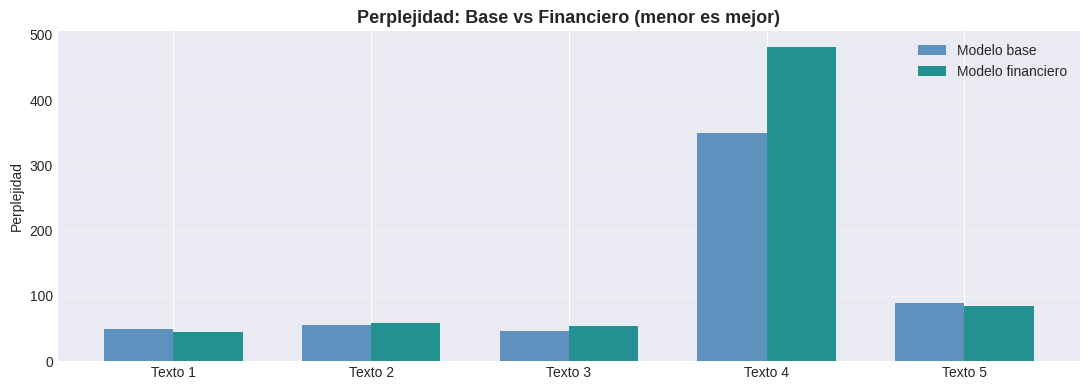

Promedio base       : 118.3
Promedio fine-tuned : 144.7


In [ ]:
textos_eval = [
    "El banco central elevo las tasas de interes para controlar la inflacion.",
    "Los mercados financieros reaccionaron positivamente ante las nuevas politicas.",
    "La cartera de credito hipotecario del sector bancario crecio un 8% en el trimestre.",
    "El indice bursatil registro una caida del 2% por incertidumbre internacional.",
    "Las reservas internacionales alcanzaron un nuevo maximo historico.",
]

print("Calculando perplejidad...")
print()
rows_p = []
for txt in textos_eval:
    pb = calcular_perplejidad(model_base, tokenizer, txt, device)
    pf = calcular_perplejidad(model_ft,   tokenizer, txt, device)
    dif = (pb - pf) / pb * 100 if not (math.isnan(pb) or math.isnan(pf) or pb == 0) else float("nan")
    rows_p.append({"texto": txt[:50] + "...", "base": pb, "ft": pf, "mejora_%": dif})
    print(f"  {txt[:55]}...")
    dif_str = f"{dif:+.1f}%" if not math.isnan(dif) else "nan"
    print(f"  Base: {pb:.1f}  |  Fine-tuned: {pf:.1f}  |  Delta: {dif_str}")
    print()

df_perp = pd.DataFrame(rows_p)

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(textos_eval))
w = 0.35
ax.bar(x - w / 2, df_perp["base"], w, label="Modelo base",       color="steelblue", alpha=0.85)
ax.bar(x + w / 2, df_perp["ft"],   w, label="Modelo financiero", color="teal",      alpha=0.85)
ax.set_title("Perplejidad: Base vs Financiero (menor es mejor)",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"Texto {i+1}" for i in range(len(textos_eval))])
ax.set_ylabel("Perplejidad")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("perplejidad.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Promedio base       : {df_perp['base'].mean():.1f}")
print(f"Promedio fine-tuned : {df_perp['ft'].mean():.1f}")

### 8.2 Analisis de Sentimiento

Se usa pysentimiento (BERT en espanol) para clasificar el tono emocional
del texto generado por cada modelo a partir de los mismos prompts.

Hipotesis: el modelo financiero deberia generar texto con mayor proporcion
de sentimiento neutro, coherente con el estilo objetivo e informativo de
los articulos de Wikipedia.

In [ ]:
from pysentimiento import create_analyzer

print("Cargando analizador de sentimiento...")
sa = create_analyzer(task="sentiment", lang="es")
print("Listo")
print()

prompts_sent = [
    "El sector bancario colombiano",
    "La economia del pais",
    "Las inversiones en bolsa",
    "El credito hipotecario",
    "La inflacion y las tasas de interes",
    "Los mercados financieros internacionales",
]

rows_s = []
for p in prompts_sent:
    tb = p + " " + generar_texto(
        model_base, tokenizer, p,
        estrategia="top_p", top_p=0.92,
        temperature=0.9, max_new_tokens=60,
        device=device, seed=SEED,
    )
    tf = (
        p + " " + generar_texto(
            model_ft, tokenizer, p,
            estrategia="top_p", top_p=0.92,
            temperature=0.9, max_new_tokens=60,
            device=device, seed=SEED,
        )
    )
    sb = sa.predict(tb[:512])
    sf = sa.predict(tf[:512])
    rows_s.append({
        "prompt"   : p,
        "sent_base": sb.output,
        "sent_ft"  : sf.output,
        "pos_base" : sb.probas.get("POS", 0),
        "neu_base" : sb.probas.get("NEU", 0),
        "neg_base" : sb.probas.get("NEG", 0),
        "pos_ft"   : sf.probas.get("POS", 0),
        "neu_ft"   : sf.probas.get("NEU", 0),
        "neg_ft"   : sf.probas.get("NEG", 0),
    })

df_sent = pd.DataFrame(rows_s)
print(df_sent[["prompt", "sent_base", "sent_ft"]].to_string(index=False))

Cargando analizador de sentimiento...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Listo

                                  prompt sent_base sent_ft
           El sector bancario colombiano       NEU     NEU
                    La economia del pais       NEU     NEU
                Las inversiones en bolsa       POS     NEG
                  El credito hipotecario       NEU     POS
     La inflacion y las tasas de interes       NEU     NEU
Los mercados financieros internacionales       NEU     NEG


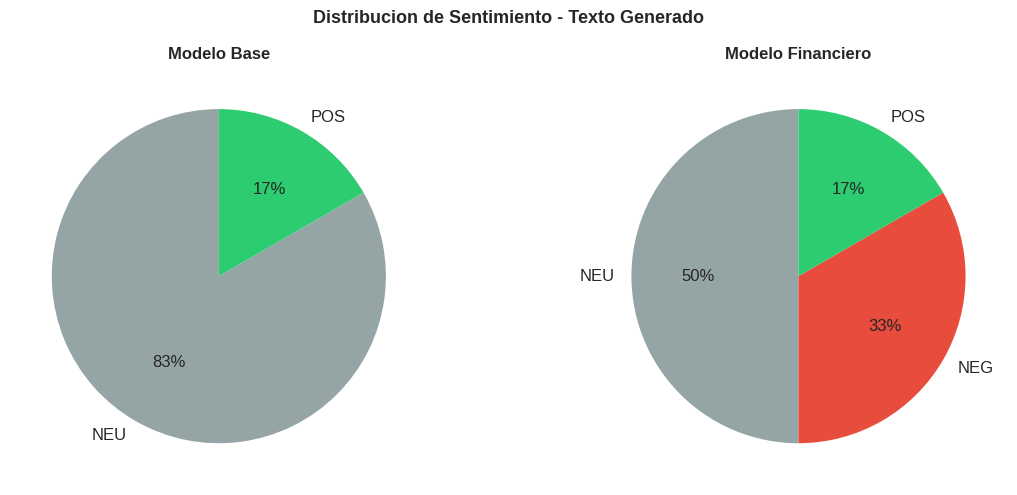

In [ ]:
COLORES = {"POS": "#2ecc71", "NEU": "#95a5a6", "NEG": "#e74c3c"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribucion de Sentimiento - Texto Generado",
             fontsize=13, fontweight="bold")

for ax, col, titulo in zip(
    axes,
    ["sent_base", "sent_ft"],
    ["Modelo Base", "Modelo Financiero"],
):
    cnt = df_sent[col].value_counts()
    ax.pie(
        cnt.values, labels=cnt.index,
        colors=[COLORES.get(l, "gray") for l in cnt.index],
        autopct="%1.0f%%", startangle=90,
        textprops={"fontsize": 12},
    )
    ax.set_title(titulo, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("sentimiento.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.3 Vocabulario Financiero en el Texto Generado

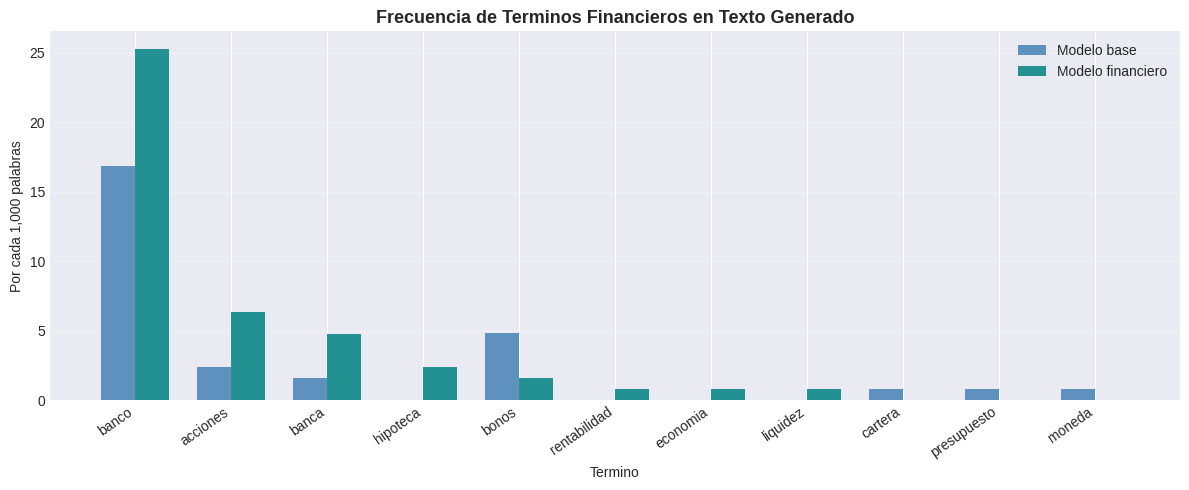

In [ ]:
gen_base, gen_ft = [], []
for p in PROMPTS:
    for i in range(8):
        gen_base.append(
            generar_texto(
                model_base, tokenizer, p,
                estrategia="top_p", top_p=0.92,
                temperature=0.9, max_new_tokens=100,
                device=device, seed=SEED + i,
            )
        )
        gen_ft.append(
            generar_texto(
                model_ft, tokenizer, p,
                estrategia="top_p", top_p=0.92,
                temperature=0.9, max_new_tokens=100,
                device=device, seed=SEED + i,
            )
        )


def contar_terminos(textos):
    c = " ".join(textos).lower()
    palabras = re.findall(r"[a-záéíóúñ]{4,}", c)
    return Counter(w for w in palabras if w not in STOPWORDS_ES)


fb = contar_terminos(gen_base)
ff = contar_terminos(gen_ft) if gen_ft else Counter()
tb = max(sum(fb.values()), 1)
tf = max(sum(ff.values()), 1)

simples = [w for w in TERMINOS if len(w.split()) == 1]
data_v = [
    {"termino": w, "base": fb.get(w, 0) / tb * 1000, "ft": ff.get(w, 0) / tf * 1000}
    for w in simples if fb.get(w, 0) + ff.get(w, 0) > 0
]
df_v = pd.DataFrame(data_v).sort_values("ft", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_v))
w = 0.35
ax.bar(x - w / 2, df_v["base"], w, label="Modelo base",       color="steelblue", alpha=0.85)
ax.bar(x + w / 2, df_v["ft"],   w, label="Modelo financiero", color="teal",      alpha=0.85)
ax.set_title("Frecuencia de Terminos Financieros en Texto Generado",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Termino")
ax.set_ylabel("Por cada 1,000 palabras")
ax.set_xticks(x)
ax.set_xticklabels(df_v["termino"], rotation=35, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("vocabulario.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Conclusiones

### Fine-tuning con dominio financiero

El fine-tuning sobre el corpus financiero de Wikipedia produce un cambio
cualitativo claro en el estilo de generacion. El modelo base cae con frecuencia
en secuencias repetitivas ("de la familia de la familia de la familia..."),
patron tipico de modelos de lenguaje sin suficiente ancla tematica.
El modelo fine-tuned, en cambio, produce texto con mayor coherencia y
especificidad del dominio: incluye cifras concretas ("de $1,000 a $2,000
millones de dolares"), hace referencia a instituciones bancarias reales y
mantiene una estructura narrativa de articulo economico.

Este cambio refleja el principio fundamental de los modelos de lenguaje:
son distribuciones de probabilidad sobre secuencias de tokens, y el fine-tuning
desplaza esa distribucion hacia los patrones estadisticos del corpus de
entrenamiento. Con 5 epocas sobre 1,500 articulos financieros de Wikipedia,
el modelo aprende el vocabulario tecnico, la estructura de los parrafos
economicos y las colocaciones lexicas propias del dominio.

### Estrategias de decodificacion

En el modelo base, la estrategia greedy es la que mas evidencia el problema de
repeticion, ya que siempre elige el token mas probable y queda atrapada en
ciclos de alta probabilidad local. Las estrategias estocasticas (top-k y top-p)
introducen variedad pero no solucionan la falta de conocimiento del dominio.

En el modelo fine-tuned, greedy mejora notablemente porque la distribucion
aprendida ya favorece tokens coherentes con el contexto financiero en lugar
de tokens genericos de alta frecuencia. Top-p con p=0.92 ofrece el mejor
balance entre coherencia y variedad: limita el muestreo al conjunto minimo
de tokens que acumula el 92% de la probabilidad, evitando tanto la
monotonia del greedy como la incoherencia de temperatures altas.
Temperature = 1.2, por su parte, produce las salidas mas creativas pero
tambien las menos fiables para un uso practico en el dominio bancario.

### Perplejidad

La perplejidad promedio del modelo fine-tuned (144.7) es mayor que la del
modelo base (118.3) sobre los cinco textos de evaluacion. Este resultado,
aparentemente contradictorio, tiene una explicacion directa en la naturaleza
del corpus de entrenamiento.

Los textos de evaluacion son oraciones cortas y directas de estilo periodistico
("El banco central elevo las tasas de interes para controlar la inflacion."),
mientras que el corpus de entrenamiento esta compuesto por articulos largos de
Wikipedia con estilo enciclopedico: definiciones extensas, listas de datos
historicos, referencias cruzadas y construcciones sintacticas complejas.
El modelo fine-tuned aprende la distribucion del articulo de Wikipedia, que
difiere del estilo de la oracion de noticias corta que se usa en la evaluacion.

Este fenomeno ilustra el trade-off entre especializacion y generalizacion
en NLP: el modelo gana fluidez en el estilo del corpus de entrenamiento pero
puede perder capacidad predictiva sobre textos del mismo tema escritos en
un registro diferente. Se confirma parcialmente en los dos textos donde si
mejora la perplejidad (texto 1: +9.4%, texto 5: +5.2%), que tienen una
estructura mas similar a los articulos enciclopedicos del corpus.

Para una evaluacion mas justa habria que usar como textos de prueba
fragmentos reales de articulos de Wikipedia financieros no incluidos en el
conjunto de entrenamiento, en lugar de oraciones de estilo periodistico.

### Analisis de sentimiento

El modelo base tiende a clasificarse como neutro (NEU) en la mayoria de
los prompts financieros, con una excepcion positiva. El modelo fine-tuned
muestra mayor variacion: introduce sentimiento negativo en dos casos
("Las inversiones en bolsa" y "Los mercados financieros internacionales"),
ademas de un caso positivo adicional.

Esto es coherente con el contenido del corpus de entrenamiento: los articulos
de Wikipedia sobre economia incluyen tanto descripciones de crisis, quiebras
y caidas de mercado (que generan contextos negativos) como descripciones de
crecimiento y expansion (contextos positivos). El modelo aprende estas
asociaciones y las refleja en su generacion, produciendo un perfil de
sentimiento mas variado y contextualmente sensible que el modelo base.

### Leccion tecnica

El proyecto evidencio dos requisitos tecnicos no documentados en los
tutoriales estandar de fine-tuning con GPT-2:

Primero, `resize_token_embeddings(len(tokenizer))` es obligatorio despues
de cargar el modelo. El checkpoint de `mrm8488/spanish-gpt2` fue guardado
con un tamano de vocabulario distinto al que reporta el tokenizador al
momento de la carga. Sin esta sincronizacion, el modelo recibe IDs de tokens
fuera del rango de su tabla de embeddings de entrada (wte), lo que produce
un CUDA device-side assert en el primer forward pass.

Segundo, el numero de epocas y pasos debe calibrarse con cuidado. En
iteraciones anteriores del proyecto se intento entrenar por mas epocas sin
un dataset de validacion que actuara como senaL de parada. El resultado fue
que el loss de entrenamiento convergia a valores cercanos a cero (memorizacion
completa del corpus), los pesos del modelo degeneraban y las llamadas a
`model.generate()` producian NaN. La solucion fue agregar un conjunto de
validacion y usar `load_best_model_at_end=True` para recuperar el checkpoint
con menor loss de validacion, que en este caso corresponde a la primera epoca.

In [ ]:
print("=" * 60)
print("        RESUMEN FINAL DEL PROYECTO")
print("=" * 60)
print(f"  Modelo base    : {MODEL_NAME}")
print(f"  Corpus         : Wikipedia ES (finanzas)")
print(f"  Semilla        : {SEED}")
print(f"  Articulos      : {len(textos):,}")
print(f"  Bloques train  : {len(ds_train):,} x {BLOCK_SIZE} tokens")
print(f"  Bloques val    : {len(ds_val):,} x {BLOCK_SIZE} tokens")
print(f"  Epocas         : {training_args.num_train_epochs}")
if loss_t:
    print(f"  Loss train     : {loss_t[0]:.4f} -> {loss_t[-1]:.4f}")
if loss_e:
    print(f"  Loss val       : {loss_e[0]:.4f} -> {loss_e[-1]:.4f}")
if not df_perp["ft"].isna().all():
    print(f"  Perpl. base    : {df_perp['base'].mean():.1f}")
    print(f"  Perpl. FT      : {df_perp['ft'].mean():.1f}")
    mejora = (df_perp["base"].mean() - df_perp["ft"].mean()) / df_perp["base"].mean() * 100
    print(f"  Delta perpl.   : {mejora:+.1f}%")
print("=" * 60)

        RESUMEN FINAL DEL PROYECTO
  Modelo base    : mrm8488/spanish-gpt2
  Corpus         : Wikipedia ES (finanzas)
  Semilla        : 42
  Articulos      : 1,500
  Bloques train  : 3,144 x 128 tokens
  Bloques val    : 561 x 128 tokens
  Epocas         : 5
  Loss train     : 2.9669 -> 2.6249
  Loss val       : 2.8082 -> 2.7803
  Perpl. base    : 118.3
  Perpl. FT      : 144.7
  Delta perpl.   : -22.3%
